# Figure 3: Decorated Graph

Figure 3 shows how decoration changes the graph construction and produces cleaner boundary power-law correlations.

This figure includes:

* (a) boundary entropy for a decorated graph, with a decorated graph inset
* (b) position and momentum covariance decay along the boundary, with scaling-dimension fits

## Import Dependencies

In [1]:
%load_ext autoreload
%autoreload 2

import tomllib

import numpy as np

import matplotlib as mpl
import matplotlib.pyplot as plt

import networkx as nx
import graph2grav.graphs as graphs
import graph2grav.gaussian as gaussian
import graph2grav.plotting as plotting
import graph2grav.technical_helpers as helpers
from graph2grav.analysis import format_with_uncertainty

import loadconfig as loco

from copy import deepcopy

## Set Parameters and Graph Drawing Helpers

Load the shared figure settings and define the helper used to draw the decorated graph inset.

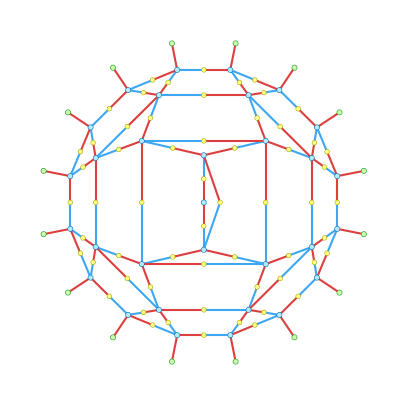

In [2]:
config = loco.reload()

%config InlineBackend.print_figure_kwargs = {'bbox_inches': "tight"}
%matplotlib inline


def build_decorated_graph_plot(ax, depth=4, remove_up_to_depth=None, use_kamada_kawai_layout=False, remove_crown=False, tweak_central_intermediate_node_position = True):
    ax.set_axis_off()

    dtree = graphs.subdivided_tree_decoration_1(depth, draw=False, remove_crown=remove_crown, remove_up_to_depth=remove_up_to_depth)

    # kamada kawai layout
    if use_kamada_kawai_layout:
        pos = nx.kamada_kawai_layout(dtree)
    else:
        def coerce(number):
            if number is None:
                return -1
            else:
                return number

        depths = np.array([coerce(dtree.nodes[n].get("depth", -1)) for n in dtree.nodes()])
        depths = depths[depths >= 0]
        numbers_of_nodes_per_depth = {wd: sum(1 for n in dtree.nodes() if coerce(dtree.nodes[n].get("depth", -1)) == wd and dtree.nodes[n]["tier"] == "primary") for wd in np.unique(depths)}
        smallest_node_label_per_depth = {wd: min(n for n in dtree.nodes() if coerce(dtree.nodes[n].get("depth", -1)) == wd and dtree.nodes[n]["tier"] == "primary") for wd in np.unique(depths)}

        pos = {}


        hyperbolic_spacing = 0.6
        pos = {}
        # max_depth = max([dtree.nodes[n].get("depth", 0) for n in dtree.nodes])


        for node in dtree.nodes():
            if dtree.nodes[node]["is_boundary"]:
                continue
            if dtree.nodes[node]["tier"] != "primary":
                continue

            euclidean_r = hyperbolic_spacing * dtree.nodes[node]["depth"]
            # max_euclidean_r = hyperbolic_spacing * max_depth


            r = np.tanh(euclidean_r / 2)  # / np.tanh(max_euclidean_r / 2)

            depth = dtree.nodes[node]["depth"]

            numbers_of_nodes = numbers_of_nodes_per_depth[depth]
            smallest_node_label = smallest_node_label_per_depth[depth]
            index_in_layer = node - smallest_node_label

            angular_spacing = 2 * np.pi / numbers_of_nodes

            angular_position = 2 * np.pi * index_in_layer / numbers_of_nodes + angular_spacing / 2

            x = r * np.cos(angular_position)
            y = r * np.sin(angular_position)



            pos[node] = np.array([x, y])
        
        for node in dtree.nodes():
            if not dtree.nodes[node]["is_boundary"]:
                continue

            r = 1
            number_of_nodes = len([n for n in dtree.nodes() if dtree.nodes[n]["is_boundary"]])
            smallest_node_label = min(n for n in dtree.nodes() if dtree.nodes[n]["is_boundary"])
            index_in_layer = node - smallest_node_label

            angular_spacing = 2 * np.pi / number_of_nodes

            angular_position = 2 * np.pi * index_in_layer / number_of_nodes + angular_spacing / 2

            x = r * np.cos(angular_position)
            y = r * np.sin(angular_position)

            pos[node] = np.array([x, y])
        
        for node in dtree.nodes():
            if dtree.nodes[node]["is_boundary"]:
                continue
            if dtree.nodes[node]["tier"] == "primary":
                continue

            connected_nodes = list(dtree.neighbors(node))

            mean_position = np.mean([pos[n] for n in connected_nodes], axis=0)
            pos[node] = mean_position

            if tweak_central_intermediate_node_position:
                if dtree.nodes[connected_nodes[0]]["depth"] == 1 and dtree.nodes[connected_nodes[1]]["depth"] == 1:
                    pos[node] = pos[node] + np.array([0.1, 0])






    def get_inner_color(node_object):
        if node_object["is_boundary"]:
            return config["graph"]["nodes"]["boundary"]["inner"]["color"]
        else:
            if node_object["tier"] == "primary":
                return config["graph"]["nodes"]["ancilla"]["inner"]["color"]
            else:
                return config["graph"]["nodes"]["ancilla_secondary"]["inner"]["color"]

    def get_outer_color(node_object):
        if node_object["is_boundary"]:
            return config["graph"]["nodes"]["boundary"]["outer"]["color"]
        else:
            if node_object["tier"] == "primary":
                return config["graph"]["nodes"]["ancilla"]["outer"]["color"]
            else:
                return config["graph"]["nodes"]["ancilla_secondary"]["outer"]["color"]
    
    def get_edge_color(edge_object):
        if edge_object["mweight"] > 0 :
            return config["decorated-figure"]["edges"]["positive"]["color"]
        else:
            return config["decorated-figure"]["edges"]["negative"]["color"]

    def get_node_size(node_object):
        if node_object["is_boundary"]:
            return config["graph"]["nodes"]["boundary"]["outer"]["size"]/4
        else:
            if node_object["tier"] == "primary":
                return config["graph"]["nodes"]["ancilla"]["outer"]["size"]/4
            else:
                return config["graph"]["nodes"]["ancilla_secondary"]["outer"]["size"]/4

    inner_premeasure = [ get_inner_color(dtree.nodes[n]) for n in dtree.nodes ]
    outer_premeasure = [ get_outer_color(dtree.nodes[n]) for n in dtree.nodes ]
    edge_colors = [ get_edge_color(dtree.edges[e]) for e in dtree.edges ]

    node_names_by_set_to_label = {
        "all": None,
        "just_boundary": {n: dtree.nodes[n]["position_in_boundary"] if dtree.nodes[n]["is_boundary"] else "" for n in dtree.nodes},
        "none": {n: "" for n in dtree.nodes}
    }

    outer_node_sizes = [ get_node_size(dtree.nodes[n])/2 for n in dtree.nodes ]

    graph_to_draw = dtree

    nx.draw_networkx_nodes(graph_to_draw, pos , ax=ax, node_color=outer_premeasure, node_size=outer_node_sizes)
    nx.draw_networkx_nodes(graph_to_draw, pos , ax=ax, node_color=inner_premeasure, node_size=np.array(outer_node_sizes)/2)

    nx.draw_networkx_edges(graph_to_draw, pos, ax=ax, edgelist=graph_to_draw.edges, edge_color=edge_colors, width=1.5)
    nx.draw_networkx_labels(graph_to_draw, pos, ax=ax, labels=node_names_by_set_to_label[config["graph"]["which_nodes_to_label"]], font_color="black")




fig, ax = plt.subplots(
    1, 1, figsize=(
        config["decorated-figure"]["column-1"]["width"]*1,
        config["decorated-figure"]["column-1"]["height"]*1
    ),
)

build_decorated_graph_plot(ax)

## Define Analysis Helpers

Extend the shared analysis object with notebook-specific plotting helpers for decorated correlations.

In [3]:
from graph2grav.analysis import Analysis as BaseAnalysis


def periodic_CFT_entropy(length, total_length, central_charge=1, offset=0):
    """
    Returns the entanglement entropy for a contiguous region of given length of a periodic 1+1D CFT.
    `total_length` is the length of the entire system, and `central_charge` is the central charge of the CFT.
    """
    return (central_charge / 3) * np.log(np.sin(np.pi * length / total_length)) + offset


class DecoratedAnalysis(BaseAnalysis):
    """Extended Analysis with notebook-specific plotting methods for decorated graphs."""

    def __init__(self, graph, couplingtime=1, global_presqueeze=1, fraction_to_ignore=1/3):
        super().__init__(
            graph,
            couplingtime=couplingtime,
            global_presqueeze=global_presqueeze,
            is_decorated=True,
            fraction_to_exclude_for_scaling_fit=fraction_to_ignore,
        )
        self.fraction_to_ignore = fraction_to_ignore
        
        # Perform fits (opt-in in base class)
        self.fit_central_charge()
        self.fit_position_scaling_dimension(fraction_to_ignore)
        self.fit_momentum_scaling_dimension(fraction_to_ignore)

    # Override xlabel to use different variable name
    @property
    def xlabel(self):
        if self.periodic:
            return r"$\sin(\pi d / L)$"
        else:
            return r"Site $d$"

    def plot_position_scaling_fit(self, ax=None, color="black", label=None, scaling_dimension=None):
        """Plot power-law fit for position covariance (alias for plot_position_powerlaw)."""
        if ax is None:
            ax = plt.gca()
        ax.loglog(
            self.xs[1:],
            self.position_normalization * self.xs[1:] ** (-2 * (scaling_dimension if scaling_dimension is not None else self.position_scaling_dimension)),
            label=label,
            color=color
        )

    def plot_momentum_scaling_fit(self, ax=None, color="black", label=None, scaling_dimension=None):
        """Plot power-law fit for momentum covariance (alias for plot_momentum_powerlaw)."""
        if ax is None:
            ax = plt.gca()
        ax.loglog(
            self.xs[1:],
            self.momentum_normalization * self.xs[1:] ** (-2 * (scaling_dimension if scaling_dimension is not None else self.momentum_scaling_dimension)),
            label=label,
            color=color
        )

    def plot_entanglement_entropy(self, ax, include_ends=False, zorder=None, markersize=None, alpha=None, color=None):
        """Plot entanglement entropy (simple marker style)."""
        if include_ends:
            ax.plot(self.region_sizes, self.boundary_entropies, "o", alpha=alpha, 
                    color=color or config["graph"]["nodes"]["boundary"]["outer"]["color"], 
                    zorder=zorder, markersize=markersize)
        else:
            ax.plot(self.region_sizes[1:-1], self.boundary_entropies[1:-1], "o", alpha=alpha, 
                    color=color or config["graph"]["nodes"]["boundary"]["outer"]["color"], 
                    zorder=zorder, markersize=markersize)
        return ax

    def plot_momentum_covariance(self, ax=None, alpha=0.7, normalize=False, take_absolute_value=True, 
                                  subtract_zero_mode=False, legend_args={}, **kwargs):
        """Plot momentum covariance with extended options."""
        if ax is None:
            fig, ax = plt.subplots()
        nvals = len(self.xs)
        
        covariance_data = gaussian.momentum(self.boundary_after_bulk_measurement)[0, :nvals]

        if subtract_zero_mode:
            L = covariance_data.shape[0]
            ones = np.ones((L, L))
            projector = np.eye(L) - ones / L
            covariance_data = projector @ covariance_data @ projector

        if take_absolute_value:
            covariance_data = np.abs(covariance_data)

        if normalize:
            covariance_data /= covariance_data[1]
        ax.loglog(self.xs, covariance_data, "o", alpha=alpha, **kwargs)

        abs_sign = "|" if take_absolute_value else ""
        ax.set_xlabel(self.xlabel, labelpad=1)
        ax.set_ylabel(abs_sign + rf"cov($p_0$, $p_d$)" + abs_sign)

        if legend_args:
            ax.legend(**legend_args)
        return ax

    def plot_position_covariance(self, ax=None, alpha=0.7, normalize=False, take_absolute_value=True, 
                                  legend_args={}, **kwargs):
        """Plot position covariance with extended options."""
        if ax is None:
            fig, ax = plt.subplots()
        nvals = len(self.xs)

        if take_absolute_value:
            covariance_data = np.abs(gaussian.position(self.boundary_after_bulk_measurement)[0, :nvals])
        else:
            covariance_data = gaussian.position(self.boundary_after_bulk_measurement)[0, :nvals]

        if normalize:
            covariance_data /= covariance_data[1]
        ax.loglog(self.xs, covariance_data, "o", alpha=alpha, **kwargs)

        abs_sign = "|" if take_absolute_value else ""
        ax.set_xlabel(self.xlabel)
        ax.set_ylabel(abs_sign + rf"cov($x_0$, $x_d$)" + abs_sign)

        if legend_args:
            ax.legend(**legend_args)
        return ax

## Make Figure

Assemble the entropy and covariance panels, report fitted quantities, and save the paper figure.

Momentum scaling dimension: Δ_p = 1.03(3) \times 10^{-2}
Position scaling dimension: Δ_x = 8.7(4) \times 10^{-1}
Decorated Binary Tree, Depth 4, Coupling Time 1 
Fitted central charge: c = 1.004(9)
CFT entropy offset: 1.954(2)
Initial squeezing: 0.05



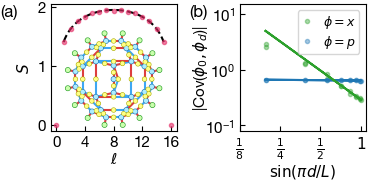

In [5]:
config = loco.reload()
from matplotlib import gridspec
from graph2grav.figure_hashing import save_figure_with_hash


bbox = mpl.transforms.Bbox.from_bounds(0, 0, 3.75, 1.875)

%config InlineBackend.print_figure_kwargs = {'bbox_inches': bbox}
%matplotlib inline

depth = 4
remove_up_to_depth = None # depth - 1
dtree = graphs.subdivided_tree_decoration_1(depth, draw=False, remove_crown=False, remove_up_to_depth=remove_up_to_depth)
couplingtime = 1
presqueezes = np.array([0.05])



fraction_to_ignore= 3 / (2**depth) # maybe should change to number to ignore
decorated_analyses = [DecoratedAnalysis(dtree, couplingtime=couplingtime, global_presqueeze=sq, fraction_to_ignore=fraction_to_ignore) for sq in presqueezes]

# 1. Standard Setup
fig = plt.figure(figsize=(bbox.width, bbox.height)) # No layout engine needed

# 2. MASTER GRID (The 3 Columns)
# This controls the global margins and the gap BETWEEN the columns.
outer_gs = gridspec.GridSpec(1, 2, figure=fig, 
                             left=0.135, right=0.975, 
                             top=0.975, bottom=0.3, 
                             wspace=0.5, # Gap between the major columns
                             width_ratios=[2.5, 2.5]) 

# 3. NESTED GRIDS (The Internals)

axs = {}


# gs_right = gridspec.GridSpecFromSubplotSpec(3, 1, subplot_spec=outer_gs[1], hspace=0.8, height_ratios=[1, 1, 0.25])
axs["entanglement"] = fig.add_subplot(outer_gs[0])
axs["covariances"] = fig.add_subplot(outer_gs[1])




entanglement_ax = axs["entanglement"]
momentum_ax = axs["covariances"]
position_ax = axs["covariances"]

pos = entanglement_ax.get_position()
decorated_ax = fig.add_axes(pos, frameon=False)

build_decorated_graph_plot(decorated_ax, depth=depth, remove_up_to_depth=remove_up_to_depth)

decorated_ax.set_xlim(-1.35, 1.35)

x0, x1 = decorated_ax.get_xlim()
xrange = x1 - x0

fig = decorated_ax.figure
fig.canvas.draw()
bbox = decorated_ax.get_window_extent()
box_aspect = bbox.height / bbox.width

y_center = 0.25  # pick what you want
yrange = xrange * box_aspect
decorated_ax.set_ylim(y_center - yrange/2, y_center + yrange/2)



# make decorated ax square
# decorated_ax.set_aspect('equal', adjustable='box')

momentum_ax.sharey(position_ax)

normalize=False

black_for_fits = False
alpha = 0.6
markersize=3


for n, da in enumerate(decorated_analyses):
    # place legend below each figure
    da.plot_position_covariance(normalize=normalize, ax=position_ax, alpha=alpha/1.5, take_absolute_value=True, markersize=markersize, color="tab:green", label="$\\phi=x$")
    da.plot_momentum_covariance(normalize=normalize, ax=momentum_ax, alpha=alpha/1.5, take_absolute_value=True, markersize=markersize, color="tab:blue", label="$\\phi=p$")
    # da.plot_momentum_covariance(normalize=normalize, ax=momentum_ax, alpha=alpha, subtract_zero_mode=True, take_absolute_value=True, markersize=markersize, color="tab:purple", label="$\\phi=p (no zero mode)$")
    da.plot_entanglement_entropy(ax=entanglement_ax, include_ends=True, alpha=alpha, color=config["graph"]["nodes"]["selected_boundary"]["ryu_takayanagi"]["color"], markersize=markersize)
    # position_ax.set_yscale("linear")
    momentum_ax.set_ylabel("|Cov($\\phi_0, \\phi_d$)|")

    fine_lengths = np.linspace(1, da.boundary_length-1, 1000)
    
    entanglement_ax.plot(
        fine_lengths,
        periodic_CFT_entropy(fine_lengths, da.boundary_length, central_charge=da.central_charge, offset=da.cft_entropy_offset),
        "--",
        label=rf"$c = {da.central_charge:.3f}$",
        color="black",
        zorder=-2
    )
    entanglement_ax.set_xlabel("$\\ell$", labelpad=1)
    entanglement_ax.set_ylabel("$S$")

    da.plot_momentum_scaling_fit(
        scaling_dimension=da.momentum_scaling_dimension, ax=momentum_ax, color="black" if black_for_fits else f"tab:blue",
        label=None # rf"$\Delta_p = {da.momentum_scaling_dimension:.3f}$"
                                 )
    da.plot_position_scaling_fit(
        scaling_dimension=da.position_scaling_dimension, ax=position_ax, color="black" if black_for_fits else f"tab:green",
        label=None # rf"$\Delta_x = {da.position_scaling_dimension:.3f}$"
    )

    # Print fit parameters with uncertainties
    print(f"Momentum scaling dimension: Δ_p = {format_with_uncertainty(da.momentum_scaling_dimension, da.momentum_scaling_dimension_stderr)}")
    print(f"Position scaling dimension: Δ_x = {format_with_uncertainty(da.position_scaling_dimension, da.position_scaling_dimension_stderr)}")

# entanglement_ax.legend()

import matplotlib.ticker as mticker
for ax in [momentum_ax, position_ax]:
    ax.xaxis.set_major_formatter(mticker.NullFormatter())
    ax.xaxis.set_minor_formatter(mticker.NullFormatter())
    ax.minorticks_off()
    ax.set_xticks([1/8, 1/4, 1/2, 1])
    ax.set_xticklabels([r"$\frac{1}{8}$", r"$\frac{1}{4}$", r"$\frac{1}{2}$", r"$1$"])
# momentum_ax.set_xscale("linear")
print(f"Decorated binary tree, R_b={depth}, coupling time {couplingtime} " + ("(Normalized Covariances to First Distance)" if normalize else ""))
# position_ax.set_yscale("linear")
pass

entanglement_ax.set_xticks([0, 2**depth/4, 2**depth/2, 3*2**depth/4, 2**depth])

# move momentum_ax y label closer in
momentum_ax.yaxis.labelpad = -3

# decorated_ax.set_xlim(-1.1, 1.1)
# decorated_ax.set_ylim(-1.5, 1.5)

momentum_ax.set_ylim(0.08, 15)

# Print central charge with uncertainty
print(f"Fitted central charge: c = {format_with_uncertainty(decorated_analyses[0].central_charge, decorated_analyses[0].central_charge_stderr)}")
print(f"CFT entropy offset: {format_with_uncertainty(decorated_analyses[0].cft_entropy_offset, decorated_analyses[0].cft_entropy_offset_stderr)}")



entanglement_ax.text(-0.4, 1, f'(a)', transform=entanglement_ax.transAxes,
        fontsize=config['subfigure-label']['font']['size'], fontweight='bold', va='top', ha='left')

momentum_ax.text(-0.4, 1, f'(b)', transform=momentum_ax.transAxes,
        fontsize=config['subfigure-label']['font']['size'], fontweight='bold', va='top', ha='left')

momentum_ax.legend(ncol=1, fontsize=9, borderpad=0.25, labelspacing=0.25, handlelength=1) #  loc="center right", bbox_to_anchor=(-0.2, 0.6))

print("Initial squeezing:", presqueezes[0])
print()

if export_figure := True:
    save_figure_with_hash(fig, "figures/figure_3_decorated.pdf")